# **4x4 Grid Example for Contiguity, Adjacency and Spatial Weight Matrices**



- $A$ encodes who is a neighbor (rook vs queen),
- $D$ counts how many neighbors each cell has,
- $W=D^{−1} A$ turns sums into averages,
- $L=D−A$ measures difference from neighbors
- Applying $A$ or $W$ to $vec(X)$ matches the familiar stencil computations on the grid


In [ ]:
# Tiny 4×4 example for Rook & Queen: build A_rook, A_queen, D, W, L, and verify W x equals raster stencil averages.

import numpy as np

# ----- Helpers -----
def chain_adj(k: int) -> np.ndarray:
    """1D chain adjacency (no wrap)."""
    A = np.zeros((k,k), dtype=int)
    for i in range(k-1):
        A[i, i+1] = 1
        A[i+1, i] = 1
    return A

def row_standardize(A: np.ndarray) -> np.ndarray:
    deg = A.sum(axis=1, keepdims=True).astype(float)
    W = np.divide(A, deg, out=np.zeros_like(A, dtype=float), where=deg>0)
    return W

def print_mat(name, M, fmt="{:>6.2f}", max_rows=16, max_cols=16):
    print(f"\n{name} (shape={M.shape}):")
    # format numeric for compact readability
    if M.dtype.kind in "iu":
        fmt = "{:>3d}"
    rows, cols = M.shape
    for i in range(min(rows, max_rows)):
        row = []
        for j in range(min(cols, max_cols)):
            row.append(fmt.format(M[i,j]))
        print(" ".join(row))
    if rows>max_rows or cols>max_cols:
        print("...")

# ----- Grid size -----
m, n = 4, 4           # 4×4 grid
N = m * n

# 1D pieces
Cm = chain_adj(m)     # vertical (rows)
Cn = chain_adj(n)     # horizontal (cols)
Im = np.eye(m, dtype=int)
In = np.eye(n, dtype=int)

# Kronecker constructions
A_rook  = np.kron(In, Cm) + np.kron(Cn, Im)
A_queen = A_rook + np.kron(Cn, Cm)

# Degree, weights, Laplacian (for rook)
deg_rook  = A_rook.sum(axis=1)
D_rook    = np.diag(deg_rook)
W_rook    = row_standardize(A_rook)
L_rook    = D_rook - A_rook

# Degree, weights, Laplacian (for queen)
deg_queen = A_queen.sum(axis=1)
D_queen   = np.diag(deg_queen)
W_queen   = row_standardize(A_queen)
L_queen   = D_queen - A_queen

# ----- Toy raster X (values 1..16), vectorized x -----
X = np.arange(1, N+1).reshape(m, n)  # 1..16 laid out row-major
x = X.ravel(order="C")               # vec(X)

# ----- Apply via big matrices vs 2D stencils -----
# Rook stencil sum on grid: Cm @ X + X @ Cn^T
rook_sum_grid = Cm @ X + X @ Cn.T
rook_sum_vec  = rook_sum_grid.ravel(order="C")
rook_sum_vec_fromA = A_rook @ x

# Rook average on grid: divide by degree per cell
rook_deg_grid = deg_rook.reshape(m, n)
rook_avg_grid = np.divide(rook_sum_grid, rook_deg_grid, where=rook_deg_grid>0)
rook_avg_vec  = rook_avg_grid.ravel(order="C")
rook_avg_vec_fromW = W_rook @ x

# Queen stencil sum on grid: Cm @ X + X @ Cn^T + Cm @ X @ Cn^T
queen_sum_grid = Cm @ X + X @ Cn.T + Cm @ X @ Cn.T
queen_sum_vec  = queen_sum_grid.ravel(order="C")
queen_sum_vec_fromA = A_queen @ x

queen_deg_grid = deg_queen.reshape(m, n)
queen_avg_grid = np.divide(queen_sum_grid, queen_deg_grid, where=queen_deg_grid>0)
queen_avg_vec  = queen_avg_grid.ravel(order="C")
queen_avg_vec_fromW = W_queen @ x

# ----- Print matrices -----
print_mat("A_rook (adjacency, 4-neighbors)", A_rook, fmt="{:>2d}")
print_mat("A_queen (adjacency, 8-neighbors)", A_queen, fmt="{:>2d}")
print_mat("D_rook (degree diag)", D_rook, fmt="{:>2d}")
print_mat("W_rook (row-standardized)", W_rook, fmt="{:>6.2f}")
print_mat("L_rook (D - A)", L_rook, fmt="{:>2d}")
print_mat("D_queen (degree diag)", D_queen, fmt="{:>2d}")
print_mat("W_queen (row-standardized)", W_queen, fmt="{:>6.2f}")
print_mat("L_queen (D - A)", L_queen, fmt="{:>2d}")

# ----- Verify equality statements -----
print("\nVerification (Rook):")
print("A_rook @ x equals rook_sum_vec? ", np.allclose(rook_sum_vec_fromA, rook_sum_vec))
print("W_rook @ x equals rook_avg_vec? ", np.allclose(rook_avg_vec_fromW, rook_avg_vec))

print("\nVerification (Queen):")
print("A_queen @ x equals queen_sum_vec? ", np.allclose(queen_sum_vec_fromA, queen_sum_vec))
print("W_queen @ x equals queen_avg_vec? ", np.allclose(queen_avg_vec_fromW, queen_avg_vec))

# Show the raster results clearly
print("\nToy raster X (values 1..16):\n", X)
print("\nRook neighbor SUM (grid):\n", rook_sum_grid)
print("\nRook neighbor AVERAGE (grid)  == reshape(W_rook @ x):\n", rook_avg_grid)
print("\nQueen neighbor SUM (grid):\n", queen_sum_grid)
print("\nQueen neighbor AVERAGE (grid) == reshape(W_queen @ x):\n", queen_avg_grid)



A_rook (adjacency, 4-neighbors) (shape=(16, 16)):
  0   1   0   0   1   0   0   0   0   0   0   0   0   0   0   0
  1   0   1   0   0   1   0   0   0   0   0   0   0   0   0   0
  0   1   0   1   0   0   1   0   0   0   0   0   0   0   0   0
  0   0   1   0   0   0   0   1   0   0   0   0   0   0   0   0
  1   0   0   0   0   1   0   0   1   0   0   0   0   0   0   0
  0   1   0   0   1   0   1   0   0   1   0   0   0   0   0   0
  0   0   1   0   0   1   0   1   0   0   1   0   0   0   0   0
  0   0   0   1   0   0   1   0   0   0   0   1   0   0   0   0
  0   0   0   0   1   0   0   0   0   1   0   0   1   0   0   0
  0   0   0   0   0   1   0   0   1   0   1   0   0   1   0   0
  0   0   0   0   0   0   1   0   0   1   0   1   0   0   1   0
  0   0   0   0   0   0   0   1   0   0   1   0   0   0   0   1
  0   0   0   0   0   0   0   0   1   0   0   0   0   1   0   0
  0   0   0   0   0   0   0   0   0   1   0   0   1   0   1   0
  0   0   0   0   0   0   0   0   0   0   1   0   0  

### Tiny 4×4 Rook & Queen: Linear-Algebra Summary

We index an $m\times n$ grid (here $m=n=4$, so $N=mn=16$).  
Stack values row-major: $x=\mathrm{vec}(X)\in\mathbb{R}^{N}$.

**1D chain adjacencies (no wrap):**
- $C_m\in\mathbb{R}^{m\times m}$ on rows, $C_n\in\mathbb{R}^{n\times n}$ on columns.
- Identities $I_m, I_n$.

**Rook (4-neighbors) adjacency**
$$
A_{\text{rook}} \;=\; I_n\otimes C_m \;+\; C_n\otimes I_m.
$$

**Queen (8-neighbors) adjacency**
$$
A_{\text{queen}} \;=\; A_{\text{rook}} \;+\; C_n\otimes C_m.
$$

**Degrees, weights, Laplacians**
$$
D \;=\; \operatorname{diag}(A\mathbf{1}), \qquad
W \;=\; D^{-1}A, \qquad
L \;=\; D - A.
$$

> Rook degrees on a rectangle: corners $=2$, edges $=3$, interior $=4$.  
> Queen degrees: corners $=3$, edges $=5$, interior $=8$.

---

#### Stencil equivalences on a raster $X\in\mathbb{R}^{m\times n}$

**Rook — neighbor *sum* (matrix form)**  
Let $x=\mathrm{vec}(X)$.
$$
A_{\text{rook}}\,x \;=\; \mathrm{vec}\!\big(C_m X \;+\; X C_n^\top\big).
$$

**Rook — neighbor *average* (row-standardized)**  
Let $d^{\text{rook}} = A_{\text{rook}}\mathbf{1}\in\mathbb{R}^{N}$ and reshape it to $m\times n$.
Using elementwise division $\oslash$,
$$
W_{\text{rook}}\,x \;=\;
\mathrm{vec}\!\left(\big(C_m X + X C_n^\top\big)\;\oslash\;\operatorname{reshape}\!\big(d^{\text{rook}},\,m,n\big)\right).
$$

**Queen — neighbor *sum***
$$
A_{\text{queen}}\,x \;=\;
\mathrm{vec}\!\big(C_m X \;+\; X C_n^\top \;+\; C_m X C_n^\top\big).
$$

**Queen — neighbor *average* (row-standardized)**  
Let $d^{\text{queen}} = A_{\text{queen}}\mathbf{1}$.
$$
W_{\text{queen}}\,x \;=\;
\mathrm{vec}\!\left(\big(C_m X + X C_n^\top + C_m X C_n^\top\big)\;\oslash\;\operatorname{reshape}\!\big(d^{\text{queen}},\,m,n\big)\right).
$$

---

**Notes**
- $\otimes$ is the Kronecker product; $\mathrm{vec}(\cdot)$ stacks columns (or rows—use a consistent convention across code and math).
- The equalities show that multiplying by $A$ (or $W$) matches applying the corresponding **rook/queen stencil** and (optionally) averaging by the local degree.



# Extension: Spatial Autocorrelation (Moran's I, Geary's C) and Local Moran (LISA)

*Auto-generated on* **2025-10-06 19:42:49**

This extension builds on the *ToyRaster_Contiguity* notebook to add:
- Global **Moran's I** and **Geary's C** for both **rook** and **queen** contiguity.
- **Local Moran's I (LISA)** maps for cluster/outlier diagnostics.
- Small, dependency-free implementations (NumPy optional; pure Python fallbacks) to keep this portable.


In [ ]:

# If your original notebook already defines `X` (the raster) or adjacency helpers, we will try to use them.
# Otherwise, we set up a toy raster here and helpers for contiguity.

import math
import random

try:
    import numpy as np
except Exception:
    np = None

# --- Raster ---
# If `X` exists, reuse; else define a 4x4 toy raster with distinct values
if 'X' not in globals():
    X = [
        [1,  2,  3,  4],
        [5,  6,  7,  8],
        [9, 10, 11, 12],
        [13,14, 15, 16],
    ]

# Convert to flat vector
def raster_to_vec(X):
    if np is not None:
        return np.array(X, dtype=float).reshape(-1)
    else:
        return [float(v) for row in X for v in row]

x = raster_to_vec(X)
n = len(x)

# Grid shape
H = len(X)
W = len(X[0]) if H>0 else 0

def idx_rc(r, c): # row-major index
    return r*W + c

def neighbors_rook(r, c, H, W):
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1)]:
        rr, cc = r+dr, c+dc
        if 0<=rr<H and 0<=cc<W:
            yield rr, cc

def neighbors_queen(r, c, H, W):
    for dr in (-1,0,1):
        for dc in (-1,0,1):
            if dr==0 and dc==0:
                continue
            rr, cc = r+dr, c+dc
            if 0<=rr<H and 0<=cc<W:
                yield rr, cc

def build_W(H, W, mode="rook", row_standardize=True):
    # Sparse representation as list of dicts: W[i] = {j: w_ij,...}
    N = H*W
    Wlist = [dict() for _ in range(N)]
    neigh_fn = neighbors_rook if mode=="rook" else neighbors_queen
    for r in range(H):
        for c in range(W):
            i = idx_rc(r,c)
            nbrs = list(neigh_fn(r,c,H,W))
            deg = len(nbrs)
            if deg==0:
                continue
            val = 1.0/deg if row_standardize else 1.0
            for (rr, cc) in nbrs:
                j = idx_rc(rr,cc)
                Wlist[i][j] = val
    return Wlist

def sum_weights(Wlist):
    # S0 = sum_i sum_j w_ij
    return sum(sum(row.values()) for row in Wlist)

def spatial_lag(Wlist, z):
    # y = W z
    N = len(z)
    out = [0.0]*N
    for i in range(N):
        s = 0.0
        row = Wlist[i]
        for j, wij in row.items():
            s += wij * z[j]
        out[i] = s
    return out

def vec_mean(v):
    if np is not None and isinstance(v, np.ndarray):
        return float(v.mean())
    return sum(v)/len(v)

def vec_center(v):
    mu = vec_mean(v)
    if np is not None and isinstance(v, np.ndarray):
        return v - mu
    return [vi - mu for vi in v]

def dot(a,b):
    if np is not None and isinstance(a, np.ndarray):
        return float((a*b).sum())
    return sum(x*y for x,y in zip(a,b))

def ssq(v):
    return dot(v,v)

def morans_I(x, Wlist):
    n = len(x)
    z = vec_center(x)
    S0 = sum_weights(Wlist)
    # z' W z
    Wz = spatial_lag(Wlist, z)
    num = dot(z, Wz)
    den = ssq(z)
    return (n / S0) * (num / den)

def gearys_C(x, Wlist):
    n = len(x)
    z = vec_center(x)
    S0 = sum_weights(Wlist)
    # sum_ij w_ij (x_i - x_j)^2
    num = 0.0
    # We'll iterate i then row neighbors j
    for i, row in enumerate(Wlist):
        xi = x[i]
        for j, wij in row.items():
            num += wij * (xi - x[j])**2
    den = ssq(z)
    return ((n - 1) / (2.0 * S0)) * (num / den)

def local_moran_I(x, Wlist):
    # Ii = z_i * sum_j w_ij z_j
    z = vec_center(x)
    Wz = spatial_lag(Wlist, z)
    if np is not None and isinstance(z, np.ndarray):
        return z * Wz
    else:
        return [zi*wi for zi,wi in zip(z,Wz)]

def permutation_pvalue(stat_fn, x, Wlist, perms=499, seed=42):
    # Permutation p-value (greater for Moran's I, two-sided for Geary's C typically)
    rnd = random.Random(seed)
    base = stat_fn(x, Wlist)
    cnt = 0
    idx = list(range(len(x)))
    for _ in range(perms):
        rnd.shuffle(idx)
        x_perm = [x[i] for i in idx]
        s = stat_fn(x_perm, Wlist)
        if s >= base:
            cnt += 1
    # +1 for observed (conservative)
    return (cnt + 1) / (perms + 1), base



## Global Spatial Autocorrelation

### Moran's I
\[
I = \frac{n}{S_0} \frac{\mathbf{z}^\top W\, \mathbf{z}}{\mathbf{z}^\top \mathbf{z}},
\quad \text{where } \mathbf{z} = \mathbf{x} - \bar{x}, \; S_0 = \sum_i \sum_j w_{ij}.
\]

- \( I > 0 \): positive autocorrelation (similar values cluster)
- \( I < 0 \): negative autocorrelation (checkerboard / dissimilar neighbors)
- \( I \approx 0 \): spatial randomness (given W)

### Geary's C
\[
C = \frac{(n-1)}{2S_0} \frac{\sum_i \sum_j w_{ij} (x_i - x_j)^2}{\sum_i (x_i - \bar{x})^2}.
\]

- \( C < 1 \): positive autocorrelation
- \( C > 1 \): negative autocorrelation
- \( C \approx 1 \): spatial randomness


In [ ]:

# Build weights
W_rook  = build_W(H, W, mode="rook",  row_standardize=True)
W_queen = build_W(H, W, mode="queen", row_standardize=True)

I_rook  = morans_I(x, W_rook)
I_queen = morans_I(x, W_queen)

C_rook  = gearys_C(x, W_rook)
C_queen = gearys_C(x, W_queen)

print("Global Moran's I:")
print(f"  Rook : {I_rook:.6f}")
print(f"  Queen: {I_queen:.6f}\n")

print("Global Geary's C:")
print(f"  Rook : {C_rook:.6f}")
print(f"  Queen: {C_queen:.6f}")


Global Moran's I:
  Rook : 0.750000
  Queen: 0.620000

Global Geary's C:
  Rook : 0.187500
  Queen: 0.264063



### (Optional) Permutation Inference

We can get a rough Monte Carlo p-value by randomly permuting the attribute values across locations and recomputing the statistic.


In [ ]:

p_rook, I_rook_obs   = permutation_pvalue(morans_I, x, W_rook, perms=499, seed=123)
p_queen, I_queen_obs = permutation_pvalue(morans_I, x, W_queen, perms=499, seed=123)

print("Permutation p-values for Moran's I (greater):")
print(f"  Rook : I={I_rook_obs:.6f}, p={p_rook:.4f}")
print(f"  Queen: I={I_queen_obs:.6f}, p={p_queen:.4f}")


Permutation p-values for Moran's I (greater):
  Rook : I=0.750000, p=0.0020
  Queen: I=0.620000, p=0.0020


## **Permutation Tests (Randomization Tests)**

A permutation test is a specific kind of Monte Carlo test used to assess significance without assuming normality or independence.

**Null hypothesis (H₀):** The observed spatial pattern is random—values are exchangeable among locations.

In other words, any arrangement of the data values on the map is equally likely.

** Observed statistic:** Compute the actual Moran's I (or Geary's C) from your data and spatial weights.


### Simulated null distribution:

1. Randomly permute the attribute values among spatial units (keeping the same
𝑊 structure).

2. Recalculate Moran’s I for each permutation.

3. Repeat this many times (e.g. 499 or 999 permutations) to create an empirical distribution of 𝐼 under H₀.

### p-value estimation:
$$
p = \frac{\text{#(simulated } I_{\text{perm}} \ge I_{\text{obs}}) + 1}{\text{#permutations} + 1}
$$

This is a Monte Carlo estimate of the probability that a random spatial pattern would yield an equal or more extreme statistic than observed.

## Local Moran's I (LISA)

$$ I_i = z_i \sum_j w_{ij} z_j $$

- High-High (HH): $ z_i > 0 $ and spatial lag $ W z > 0 $ → hot spot
- Low-Low (LL): $ z_i < 0 $ and spatial lag $ W z < 0 $ → cold spot
- High-Low (HL): $ z_i > 0 $, lag $ < 0 $ → potential spatial outlier
- Low-High (LH): $ z_i < 0 $, lag $ > 0 $ → potential spatial outlier

We'll compute local Moran for both rook and queen and render as small heatmaps.

In [ ]:

try:
    import numpy as np
except Exception:
    np = None

def classify_lisa(z, Wz):
    # Return one of {"HH","LL","HL","LH"} per location
    out = []
    for zi, wi in zip(z, Wz):
        if zi >= 0 and wi >= 0:
            out.append("HH")
        elif zi < 0 and wi < 0:
            out.append("LL")
        elif zi >= 0 and wi < 0:
            out.append("HL")
        else:
            out.append("LH")
    return out

def reshape_grid(v, H, W):
    if np is not None:
        return np.array(v).reshape(H, W)
    g = [[None]*W for _ in range(H)]
    for r in range(H):
        for c in range(W):
            g[r][c] = v[r*W + c]
    return g

# Compute local Moran for rook/queen
z = vec_center(x)
Wz_rook  = spatial_lag(W_rook,  z)
Wz_queen = spatial_lag(W_queen, z)

Ii_rook  = local_moran_I(x, W_rook)
Ii_queen = local_moran_I(x, W_queen)

labels_rook  = classify_lisa(z, Wz_rook)
labels_queen = classify_lisa(z, Wz_queen)

# Reshape for display
grid_Ir  = reshape_grid(Ii_rook,  H, W)
grid_Iq  = reshape_grid(Ii_queen, H, W)
grid_lab_r = reshape_grid(labels_rook,  H, W)
grid_lab_q = reshape_grid(labels_queen, H, W)

print("Local Moran's I (rook) grid:")
for row in grid_Ir:
    print(["{:+.3f}".format(v) for v in row])

print("\nLocal Moran's I (queen) grid:")
for row in grid_Iq:
    print(["{:+.3f}".format(v) for v in row])

print("\nLISA labels (rook):")
for row in grid_lab_r:
    print(row)

print("\nLISA labels (queen):")
for row in grid_lab_q:
    print(row)


Local Moran's I (rook) grid:
['+37.500', '+33.583', '+22.917', '+13.500']
['+11.083', '+6.250', '+2.250', '+0.417']
['+0.417', '+2.250', '+6.250', '+11.083']
['+13.500', '+22.917', '+33.583', '+37.500']

Local Moran's I (queen) grid:
['+31.250', '+26.650', '+17.050', '+11.250']
['+10.150', '+6.250', '+2.250', '+0.550']
['+0.550', '+2.250', '+6.250', '+10.150']
['+11.250', '+17.050', '+26.650', '+31.250']

LISA labels (rook):
['LL' 'LL' 'LL' 'LL']
['LL' 'LL' 'LL' 'LL']
['HH' 'HH' 'HH' 'HH']
['HH' 'HH' 'HH' 'HH']

LISA labels (queen):
['LL' 'LL' 'LL' 'LL']
['LL' 'LL' 'LL' 'LL']
['HH' 'HH' 'HH' 'HH']
['HH' 'HH' 'HH' 'HH']



### Quick Visuals

The following produces simple `matplotlib` heatmaps for the raster, local Moran's I (rook/queen), and the LISA labels.  
*(Note: we avoid specifying colors per your plotting guideline unless you ask for a specific palette.)*


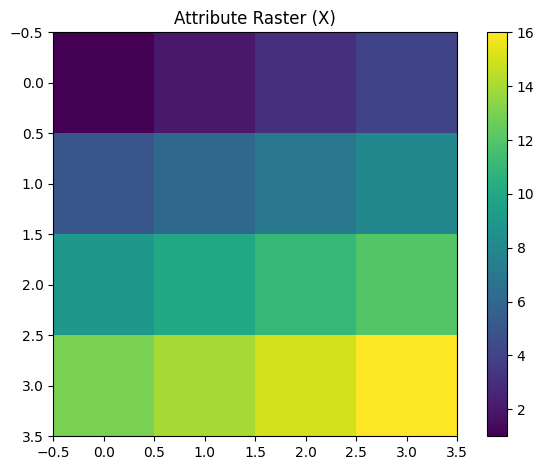

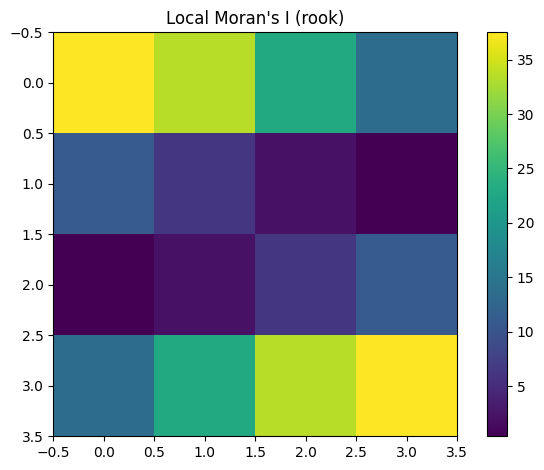

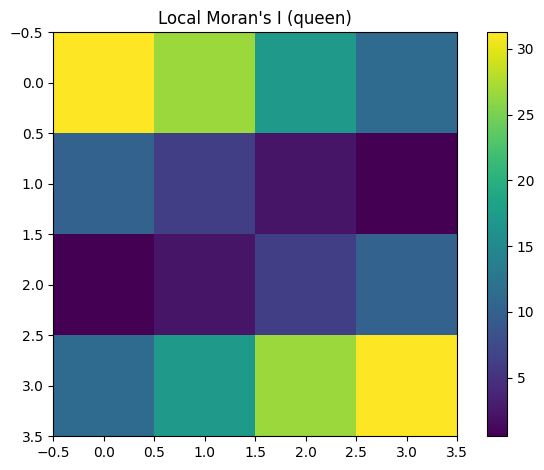

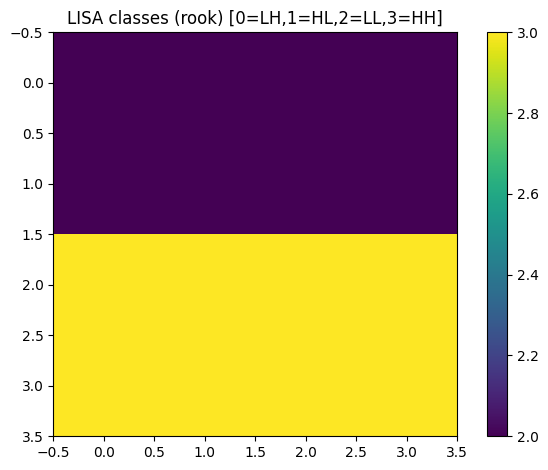

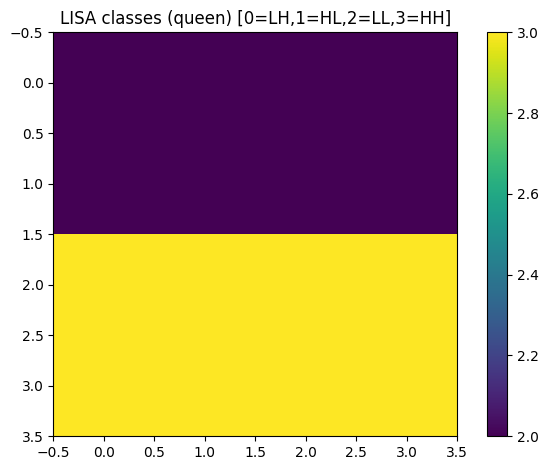

In [ ]:

import matplotlib.pyplot as plt

def plot_heatmap(grid, title):
    plt.figure()
    plt.imshow(grid)
    plt.title(title)
    plt.colorbar()
    plt.tight_layout()

# Raster
grid_X = reshape_grid(x, H, W)
plot_heatmap(grid_X, "Attribute Raster (X)")

# Local Moran's I
plot_heatmap(grid_Ir, "Local Moran's I (rook)")
plot_heatmap(grid_Iq, "Local Moran's I (queen)")

# For LISA labels, map to integers for a simple display
label_map = {"HH":3, "LL":2, "HL":1, "LH":0}
lab_r_int = [[label_map[v] for v in row] for row in grid_lab_r]
lab_q_int = [[label_map[v] for v in row] for row in grid_lab_q]
plot_heatmap(lab_r_int, "LISA classes (rook) [0=LH,1=HL,2=LL,3=HH]")
plot_heatmap(lab_q_int, "LISA classes (queen) [0=LH,1=HL,2=LL,3=HH]")

plt.show()
